In [10]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #pip install scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
sns.set_theme(style="whitegrid")
print("ML libraries imported successfully!")

ML libraries imported successfully!


In [11]:
df = pd.read_csv('test_healthcare_data.csv')
print(f"Loaded dataset: {df.shape[0]} patients and {df.shape[1]} features.")

Loaded dataset: 1000 patients and 10 features.


In [12]:
# Determine risk indicators (0 or 1)
glucose_risk = (df['glucose'] > 130).astype(int)
bp_risk = (df['blood_pressure'] > 135).astype(int)
cholesterol_risk = (df['cholesterol'] > 200).astype(int)
bmi_risk = (df['bmi'] > 28).astype(int)
age_risk = (df['age'] > 60).astype(int)

# Sum the risk factors
total_risk_score = glucose_risk + bp_risk + cholesterol_risk + bmi_risk + age_risk

# Create target variable risk_level (binary classifier)
df['risk_level'] = (total_risk_score >= 2).astype(int)

# Look at the count of healthy vs. at-risk patients
print("Original class distribution:")
print(df['risk_level'].value_counts())
print("0 = Healthy, 1 = At Risk")

Original class distribution:
risk_level
1    561
0    439
Name: count, dtype: int64
0 = Healthy, 1 = At Risk


In [13]:
# Features are all columns except 'risk_level'
X = df.drop('risk_level', axis=1)

# Target is 'risk_level'
y = df['risk_level']

print("Features (X) columns:", list(X.columns))

Features (X) columns: ['age', 'bmi', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'pregnancies', 'diabetes_pedigree', 'cholesterol', 'heart_rate']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42)

print(f"Training Set size: {X_train.shape[0]} patients")
print(f"Testing Set size: {X_test.shape[0]} patients")

Training Set size: 800 patients
Testing Set size: 200 patients


In [6]:
# Initialize model with 100 decision trees
# We set max_depth=6 to regularize the model and prevent it from over-memorizing noise!
model = RandomForestClassifier(n_estimators=100, random_state=42,
                                max_depth=6 , n_jobs=-1)

# Train model on the training data
model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [7]:
# Predict classifications on test features
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Prediction Accuracy{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Prediction Accuracy98.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        93
           1       0.98      0.99      0.99       107

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



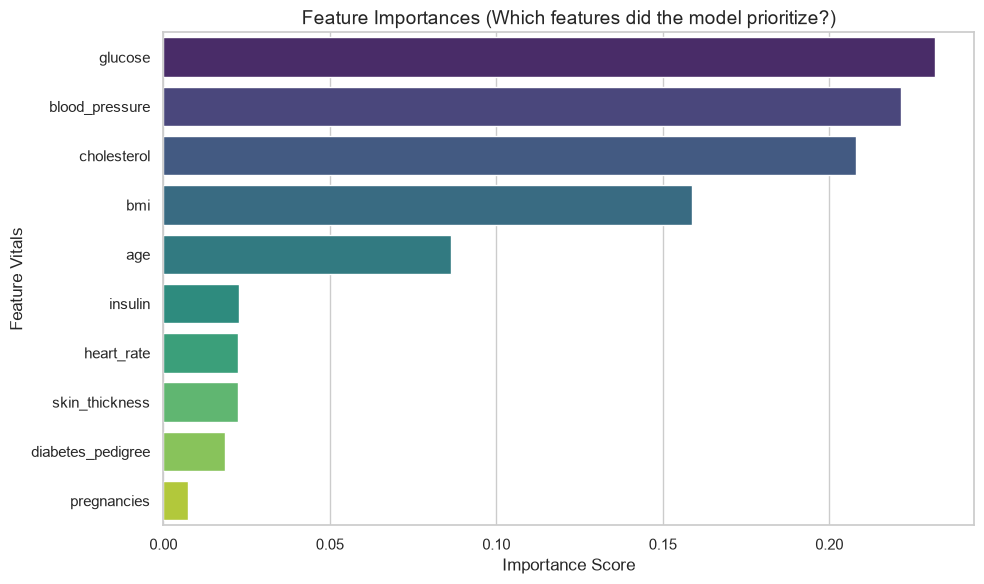

In [8]:
# Retrieve feature importances from the model
importances = model.feature_importances_

# Put them in a DataFrame for nice ordering
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=features_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances (Which features did the model prioritize?)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Vitals', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Create 'model' folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Structure model data to save both model and feature names
model_data = {'model': model  , 'features': list(X.columns)
}
# Save model utilizing pickle
model_filepath = "model/healthcare_model.pkl"
with open(model_filepath, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Trained healthcare model saved successfully to: {model_filepath}!")
print("It is now ready for use by our Streamlit web application dashboard.")

Trained healthcare model saved successfully to: model/healthcare_model.pkl!
It is now ready for use by our Streamlit web application dashboard.
